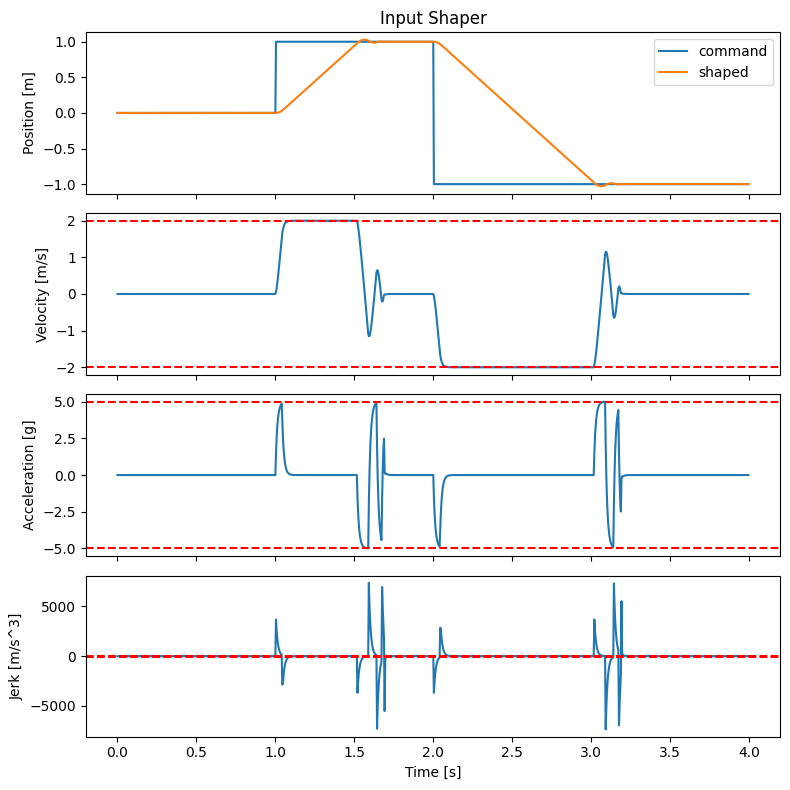

In [ ]:
import numpy
import matplotlib.pyplot as plt
dt = 1.0/250.0

g = 9.81
num_samples = int(4/dt)


x_command = []

for n in range(num_samples):

    t = n*dt

    if t > 3.0:
        x = 0.0
    if t > 2.0:
        x = -1.0
    elif t > 1.0:
        x = 1.0
    else:
        x = 0.0

    
    
    x_command.append(x)


x_command = numpy.array(x_command)

v_max = 2.0 #max velocity
a_max = 5.0*g #max acceleration
j_max = 50.0 #max jerk



class ShaperVel:
    def __init__(self, v_max,  dt=0.01):
        self.v_max = float(v_max)
        self.dt = float(dt)

        self.x_curr = 0.0

    def step(self, x_target):
      
        vel_req = (x_target - self.x_curr)/self.dt
        vel_req = numpy.clip(vel_req, -self.v_max, self.v_max)

        self.x_curr += vel_req*self.dt
            
        return self.x_curr

    def __call__(self, x_target):
        return self.step(x_target)  
    

class ShaperVelAcc:
    def __init__(self, v_max = 2.0, a_max = 50.0, alpha = 0.3, dt=0.01):

        self.v_max = float(v_max)
        self.a_max = float(a_max)
        self.dt = float(dt)

        self.alpha = alpha

        self.x = 0.0
        self.v = 0.0
        self.a = 0.0

        self.x_fil = 0.0

    def step(self, x_target):

        # requested velocity
        v_req = (x_target - self.x) / self.dt
        v_req = numpy.clip(v_req, -self.v_max, self.v_max)

        # requested acceleration
        a_req = (v_req - self.v) / self.dt
        self.a = numpy.clip(a_req, -self.a_max, self.a_max)

        # integrate acceleration
        self.v += self.a * self.dt
        self.v = numpy.clip(self.v, -self.v_max, self.v_max)

        # integrate velocity
        self.x += self.v * self.dt  

        self.x_fil = (1.0 - self.alpha)*self.x_fil + self.alpha*self.x

        return self.x_fil



#shaper = ShaperVel(v_max, dt)
shaper = ShaperVelAcc(v_max, a_max, 0.3, dt)


x_shaped = numpy.zeros(num_samples)
v_shaped = numpy.zeros(num_samples)
a_shaped = numpy.zeros(num_samples)
j_shaped = numpy.zeros(num_samples)

x_curr = 0.0

for n in range(num_samples):
    x_shaped[n] = shaper.step(x_command[n])


for n in range(num_samples):
    v_shaped[n] = (x_shaped[n] - x_shaped[n-1])/dt if n > 0 else 0.0
    a_shaped[n] = (v_shaped[n] - v_shaped[n-1])/dt if n > 0 else 0.0
    j_shaped[n] = (a_shaped[n] - a_shaped[n-1])/dt if n > 0 else 0.0



time_steps = dt*numpy.arange(num_samples)
fig, axes = plt.subplots(4, 1, figsize=(8, 8), sharex=True)

axes[0].plot(time_steps, x_command, label='command')
axes[0].plot(time_steps, x_shaped, label='shaped')
axes[0].set_ylabel('Position [m]')
axes[0].legend()
axes[0].set_title('Input Shaper')

axes[1].plot(time_steps, v_shaped)
axes[1].axhline(v_max, color='r', ls='--', label='v_max')
axes[1].axhline(-v_max, color='r', ls='--')
axes[1].set_ylabel('Velocity [m/s]')
#axes[1].legend()

axes[2].plot(time_steps, a_shaped/g)
axes[2].axhline(a_max/g, color='r', ls='--', label='a_max')
axes[2].axhline(-a_max/g, color='r', ls='--')
axes[2].set_ylabel('Acceleration [g]')
#axes[2].legend()

axes[3].plot(time_steps, j_shaped)
axes[3].axhline(j_max, color='r', ls='--', label='j_max')
axes[3].axhline(-j_max, color='r', ls='--')
axes[3].set_ylabel('Jerk [m/s^3]')
axes[3].set_xlabel('Time [s]')
#axes[3].legend()

plt.tight_layout()
plt.show()

# Detail plot around t = 1.5 s
fig2, ax2 = plt.subplots(figsize=(8, 3))
ax2.plot(time_steps, x_command, label='command')
ax2.plot(time_steps, x_shaped, label='shaped')
ax2.set_xlim(0.8, 2.2)
ax2.set_ylabel('Position [m]')
ax2.set_xlabel('Time [s]')
ax2.set_title('Position Detail around t = 1.5 s')
ax2.legend()
plt.tight_layout()
plt.show()

# S-Curve Shaper Design

The shaper works entirely in the **position domain** — no division by `dt`, no velocity integration, so it's unconditionally stable.

Each constraint on `x_next` defines a **feasible interval** from finite differences of the output history:

| Constraint | Finite difference | Feasible interval centre | Half-width |
|---|---|---|---|
| velocity  | `x_next − x₁` | `x₁` | `v_max · dt` |
| acceleration | `x_next − 2x₁ + x₂` | `2x₁ − x₂` | `a_max · dt²` |
| jerk | `x_next − 3x₁ + 3x₂ − x₃` | `3x₁ − 3x₂ + x₃` | `j_max · dt³` |

The three intervals are **intersected** to get the feasible region, then `x_target` is projected (clipped) into it. This is a single closed-form computation per step — no iteration, no integrator wind-up, no oscillation.

Set `j_max` very high to get trapezoidal (acc-limited) profiles; lower it for true S-curve rounding.